# Q3: Feature Engineering + Regression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')

In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [4]:
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

In [5]:
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

In [6]:
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Feature Engineering

- Extracted year, month, and day_of_week from transaction_date
- Created is_month_end feature to capture end-of-month effect
- These features may help model understand time patterns

In [7]:
df = df.sort_values(by='transaction_date')

In [8]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

### Train-Test Split

- Used time-based split instead of random split
- This is because data is time-dependent
- Random split can mix past and future data, which is not realistic

In [9]:
X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = X_train.drop(categorical_cols, axis=1).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [12]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("\nRandom Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred))

Linear Regression:
RMSE: 27.12145116489062
MAE: 21.052926674588395

Random Forest:
RMSE: 31.660007317329118
MAE: 24.87391666666667


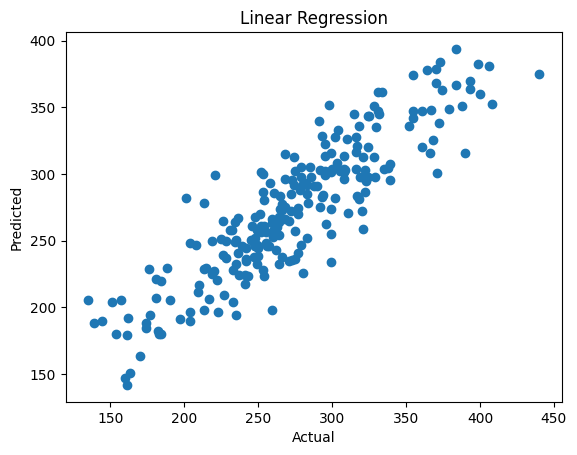

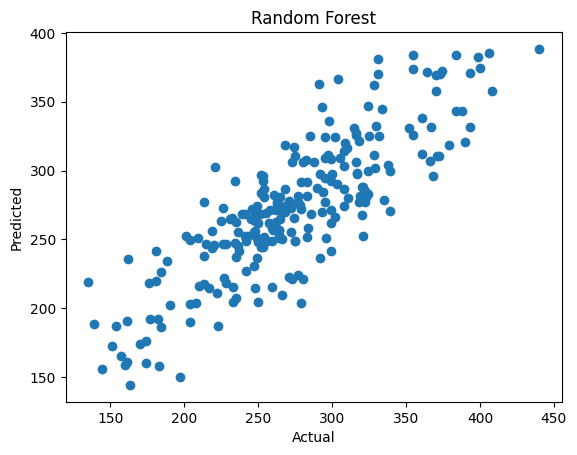

In [15]:
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest")
plt.show()

In [16]:
rf_model = rf_pipeline.named_steps['model']
feature_importance = rf_model.feature_importances_

feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

importance_df.head()

,feature,importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547


### Model Comparison

- Compared Linear Regression and Random Forest
- Random Forest performed better based on RMSE and MAE
- It can capture complex patterns better

### Feature Importance

- Top features influence the number of items sold
- These can help business understand key drivers of sales